In [41]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os

In [42]:
def make_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)

In [43]:
def making_glob_work_properly(subfolder_to_search):
    wd=os.getcwd(); os.chdir(wd+"/"+subfolder_to_search+'/')
    set_of_h5_files= glob.glob("*")
    os.chdir(wd)
    return set_of_h5_files

In [44]:
## A series of functions to parse the  simulation output
def get_run_uuid(sim_output, **kwargs):
    sim_id, sim_data = sim_output
    return(sim_id['uuid'])

def get_run_random_seed(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    random_seed = sim_ids['np.random.seed']
    return(random_seed)

def get_num_echoes_heard(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    num_echoes_heard = np.sum(sim_data[0])
    return(num_echoes_heard)

which_echo = {True: 1 , False:0}

def get_echoids(sim_data, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    echo_indices = np.argwhere(sim_data[0]==which_echo[heard]).flatten()
    return(echo_indices)    

def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output
    echo_ids = get_echoids(sim_data, **kwargs)
    
    echo_levels = sim_data[1]['target_echoes'].loc[echo_ids,'level']
    return(echo_levels)
    

def get_group_size(sim_output, **kwargs):
    ''' This function is necessary because of the
    stupid way I stored the parameter sets using classes
    '''
    sim_ids, sim_data = sim_output
    num_bats_in_group = sim_data[0].size +1 
    return(num_bats_in_group)

def split_by_groupsize(df):
    all_subdfs = []
    group_sizes = np.unique(df['groupsize'])
    for each_groupsize in group_sizes:
        subdf = df[df['groupsize']==each_groupsize]
        all_subdfs.append(subdf)
    return(group_sizes, all_subdfs)



def get_individual_positions(sim_output, **kwargs):
    '''
    '''
    sim_ids, sim_data = sim_output
    _, _b, geometry = sim_data
    positions = geometry['positions']
    return(positions)


def get_detection_distance(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    individuals_inds = echo_inds +1 # because focal individ is 0 index
    all_positions = get_individual_positions(sim_output)
    heard_individual_positions = all_positions[individuals_inds,:]
    focal_ind = all_positions[0,:]
    distances = spatial.distance
    
    positions_of_relevance = np.row_stack((focal_ind, heard_individual_positions))
    distances = spatial.distance_matrix(positions_of_relevance, 
                                        positions_of_relevance)[1:,0]
    return(distances)

def get_detection_azimuth(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_azimuth = np.array(echoes['theta'][echo_inds])
    
    return(echo_azimuth)


def get_echo_levels(sim_output, **kwargs):
    '''
    '''
    heard = kwargs.get('heard', True)
    sim_ids, sim_data = sim_output 
    echo_inds = get_echoids(sim_data, **kwargs)
    
    echoes_heard, sounds, geom = sim_data
    echoes = sounds['target_echoes']
    echo_level = np.array(echoes['level'][echo_inds])
    
    return(echo_level)
    


def get_nearest_neighbour_distances(sim_output, **kwargs):
    '''Extract the distance to the nearest neighbour of the focal bat
    
    Parameters
    -----------
    sim_output : output from a simulation run. 
    
    Keyword Arguments
    ------------------
    nearest_nbrs : int.
                    The number of distance measurements given. 
                    Defaults to 5. 


    Returns
    ---------
    nearest_neighbour_distances : 1 x nearest_nbrs np.array
    '''
    nearest_nbrs = kwargs.get('nearest_nbrs',5)
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)[1:,0]
    nearest_neighbour_distances = np.sort(distances)[:nearest_nbrs]
    return(nearest_neighbour_distances)

def get_furthest_bat2bat_distance(sim_output, **kwargs):
    '''
    '''
    positions = get_individual_positions(sim_output)
    distances = spatial.distance_matrix(positions, positions)
    furthest_distance = np.max(distances)
    return(furthest_distance)
    

def extract_parameter_values(one_sim_result, **kwargs):
    '''
    Extracts the variables from the simulation result
    by extracting the values from the 
    'parameter set'
    
    Parameters
    -----------
    one_sim_results : tuple/list with 2 entries. 
                      entry 1 should have the simulation identifiers
                      entry 2 may be anything.
    Keyword Arguments
    -----------------
    variables_to_extract : list with str.
                           The names of the variables that are to be extracted.
                           Notes: 
                           If 'source_level' is one of the variables - only the 
                           emitted levels as dBSPL is output - the reference distance
                           is *ignored*.

    Returns
    --------
    param_set : list.
                A list with the numeric or Boolean values of each of the variables extracted. 
    '''
    sim_identifiers, sim_data = one_sim_result
    all_parameter_values = sim_identifiers['parameter_set']
    
    param_set_for_this_run = []
    for each in kwargs['variables_to_extract']:
        if each != 'source_level':
            param_set_for_this_run.append(all_parameter_values[each])
        elif each == 'source_level':
            param_set_for_this_run.append(all_parameter_values[each]['dBSPL'])
    
    return(param_set_for_this_run)
        
make_to_string = lambda X: str(X)

def join_all_parameters(parameter_list):
    '''
    '''
    params_as_string = map(make_to_string, parameter_list)
    param_joined = '*'.join(params_as_string)
    return(param_joined)

def make_paramset_id(sim_output, **kwargs):
    '''
    '''
    all_parameter_values = extract_parameter_values(sim_output, **kwargs)
    param_id = join_all_parameters(all_parameter_values)
    return(param_id)


def load_simresult(path_to_simresult):
    '''
    '''
    with open(path_to_simresult, 'rb') as sim:
        output = dill.load(sim)
    return(output)

def load_and_extract(simresult_path, extraction_functions, **kwargs):
    '''
    Parameters
    ----------
    simresult_path : str/path object

    extraction_functions : list/tuple with one or more function that work on 
                            the simulation output

    Keyword Arguments
    -----------------
    As defined by the extraction functions. 
    Every key must be unique and correspond to a particular extraction function!

    Returns
    ---------
    extracted_output : object type thats returned by the extraction function
    '''
    simresult = load_simresult(simresult_path)
    extracted_outputs = [ extract(simresult, **kwargs) for extract in extraction_functions]
    return(extracted_outputs)

In [45]:
# Some functions that deal with formatting the simulation data after it's been loaded from the csv file. 

def format_nearest_neighbour_distances(nearest_nbr_entry):
    '''
    Parameters
    ----------
    nearest_nbr_entry : string. 
                        pd.DataFrame column entry with 
                        the following format 
                        '[<float>, <float>, <float>]'
    
    Returns
    -------
    np.array
    
    '''
    only_float_as_string = nearest_nbr_entry[1:-1]
    all_strings_separated = only_float_as_string.split()
    floats = map(lambda X : float(X), all_strings_separated)
    
    distances = np.array(floats)
    return(distances)
    
def split_parameters_joint_to_separate_columns(row, col_names):
    for colnam, value in zip(col_names, row['parameters_joint']):
        row[colnam] = value
    return(row)


In [46]:
results_folder = wd+"/simulations/effect_of_position_focal_bat_d/wtf is doing on truly/"
list_of_folder_ids= glob.glob(results_folder+"*")
list_of_folder_ids= [i[len(results_folder):] for i in list_of_folder_ids]
list_of_folder_ids= np.sort(list_of_folder_ids)
# # glob.glob(results_folder+"*")
list_of_folder_ids
list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
list_of_folder_ids_array_version= [(n[0][1:],n[1][1:]) for n in list_of_folder_ids_array_version]
list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])

In [47]:
def run_while_reanalysis_to_change_folder_ids(list_of_folder_ids):
    # results_folder = wd+'/analysis/task_type+'_*]'/store_results/'
    # # glob.glob(results_folder+"*")
    list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids]
    list_of_folder_ids_array_version= [(n[0][1:],n[1][1:]) for n in list_of_folder_ids_array_version]
    list_of_folder_ids_array_version= np.array([(float(n[0]), float(n[1])) for n in list_of_folder_ids_array_version])
    return list_of_folder_ids, list_of_folder_ids_array_version


In [48]:
list_of_folder_ids_array_version

array([[1.        , 1.57079633],
       [1.        , 4.71238898],
       [2.        , 1.57079633],
       [2.        , 4.71238898],
       [3.        , 1.57079633],
       [3.        , 4.71238898]])

In [49]:
folder_id= list_of_folder_ids[0]
all_results = glob.glob(results_folder+folder_id+'/*.simresults')
some_results =random.sample(all_results, int(len(all_results)*1.0))

In [50]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}

In [51]:
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]

In [52]:
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [53]:
what_to_do

'rerun'

In [62]:
if what_to_do == 'rerun':
    array_containing_all_simulation_datasets_raw = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(results_folder+str(folder_id)+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        # data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        # data_store['simulation_data'] = simulation_data
        # data_store.close()

        array_containing_all_simulation_datasets_raw.append(simulation_data)
        iterant+=1
        
# if what_to_do == 'reanalyse':
#     # show all datasets in the folder
#     data_stores_in_folder = glob.glob(task_type+'_*]')

#     datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
#     print(datastores_by_index)
#     # user-inputs dataset choice:
#     which_dataset = int(input('Give the index of the dataset you want to'))
#     print()
#     # load a pre-exisiting dataset
#     #load the saved data 
#     list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
#     # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
#     array_containing_all_simulation_datasets_raw = []
#     list_of_folder_ids, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
#     for h5_file in list_of_h5_files_in_folder:
#         data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
#         simulation_data = data_load['simulation_data']
#         array_containing_all_simulation_datasets_raw.append(simulation_data)
#         data_load.close()

# else:
#     raise IOError('Invalid input given!!')

100%|██████████| 300/300 [00:00<00:00, 1630.96it/s]


CPU times: user 206 ms, sys: 1.75 ms, total: 208 ms
Wall time: 353 ms
CPU times: user 18.1 ms, sys: 0 ns, total: 18.1 ms
Wall time: 18.1 ms


100%|██████████| 300/300 [00:00<00:00, 1565.35it/s]


CPU times: user 219 ms, sys: 2.86 ms, total: 222 ms
Wall time: 358 ms
CPU times: user 18.4 ms, sys: 0 ns, total: 18.4 ms
Wall time: 18.4 ms


100%|██████████| 200/200 [00:00<00:00, 1478.97it/s]


...

CPU times: user 130 ms, sys: 506 μs, total: 130 ms
Wall time: 248 ms
CPU times: user 12 ms, sys: 0 ns, total: 12 ms
Wall time: 12 ms


100%|██████████| 100/100 [00:00<00:00, 1538.22it/s]


CPU times: user 83.6 ms, sys: 2.15 ms, total: 85.8 ms
Wall time: 116 ms
CPU times: user 5.76 ms, sys: 0 ns, total: 5.76 ms
Wall time: 5.76 ms


100%|██████████| 100/100 [00:00<00:00, 1556.20it/s]


CPU times: user 86.3 ms, sys: 2.25 ms, total: 88.5 ms
Wall time: 124 ms
CPU times: user 6.6 ms, sys: 115 μs, total: 6.72 ms
Wall time: 6.72 ms


In [63]:
array_containing_all_simulation_datasets=[]

for simulation_data in array_containing_all_simulation_datasets_raw:
    if simulation_data["focal_bat"][0][0]==5.0 or simulation_data["focal_bat"][0][0]==6.0:
        continue
    else:
        array_containing_all_simulation_datasets.append(simulation_data)

In [64]:
def passing_true_false_indices_through_lists(list, true_false_list):
    """this is required since list doeesnt support numpy operations and non linear lists can hence not take in true false as indices"""
    output_array= []; iterant=0
    for entry in true_false_list:
        if entry:
            print(iterant)
            output_array.append(list[iterant])

        iterant+=1
    return output_array

In [65]:
array_containing_all_simulation_datasets

[     nbrs_detected  group_size  group_diameter  \
 0                4           5        1.060255   
 1                5          20        2.926273   
 2                4           5        1.254618   
 3                3           5        1.311567   
 4                0           5        1.104617   
 ..             ...         ...             ...   
 295              4           5        1.111850   
 296             10          20        2.907119   
 297              4          10        2.329674   
 298              5          10        1.942032   
 299              4           5        1.197924   
 
                             nearest_neighbour_distance  \
 0    [0.5125767864863399, 0.7364143449107325, 1.011...   
 1    [0.5410116974522788, 0.6080377140704959, 0.657...   
 2    [0.505473583354649, 0.755935137583142, 0.78355...   
 3    [0.52792260475694, 0.7196364504719484, 0.83302...   
 4    [0.5024169857166115, 0.5923643304154607, 0.946...   
 ..                             

In [66]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:,1])
list_containing_simulated_data_sorted_by_angles= {}
for angle in unique_angles_in_dataset:
    list_containing_simulated_data_sorted_by_angles[angle]= []
    sublist_true_false_labels= list_of_folder_ids_array_version[:,1]==angle
    print(sublist_true_false_labels)
    sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets_raw, sublist_true_false_labels)
    list_containing_simulated_data_sorted_by_angles[angle].append(sublist_given_angle)

[ True False  True False  True False]
0
2
4
[False  True False  True False  True]
1
3
5


In [67]:
len(array_containing_all_simulation_datasets)
list_of_folder_ids_array_version[:,1]

array([1.57079633, 4.71238898, 1.57079633, 4.71238898, 1.57079633,
       4.71238898])

In [68]:
unique_angles_in_dataset= np.unique(list_of_folder_ids_array_version[:,1])
unique_angles_in_dataset

array([1.57079633, 4.71238898])

In [69]:
list_of_folder_ids_array_version[:,1]==angle

array([False,  True, False,  True, False,  True])

In [ ]:
list_containing_simulated_data_sorted_by_angles

{1.5707963267948966: [[     nbrs_detected  group_size  group_diameter  \
   0                3           5        1.145854   
   1                2          10        1.870117   
   2                0           5        1.406237   
   3                3           5        1.486771   
   4                9          10        1.834499   
   ..             ...         ...             ...   
   195              2           5        1.274524   
   196              8          10        2.013648   
   197              4           5        1.479736   
   198              3           5        1.279378   
   199              2           5        1.141667   
   
                               nearest_neighbour_distance  \
   0    [0.5131811474464771, 0.7376015084553167, 1.021...   
   1    [0.5448561005764073, 0.5660083125871739, 0.752...   
   2    [0.5284463471007445, 0.724722848032468, 1.0359...   
   3    [0.5192136742458365, 0.9055122524691105, 1.000...   
   4    [0.529700930544689, 0.59618

In [ ]:
for subset_given_angle in list_containing_simulated_data_sorted_by_angles:
    subset= list_containing_simulated_data_sorted_by_angles[subset_given_angle]
    for item in subset:
        subset

In [ ]:
type(simulation_data["group_size"][0])

numpy.int64

1.5707963267948966


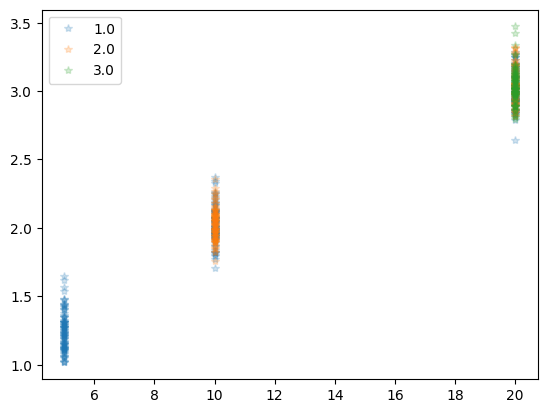

4.71238898038469


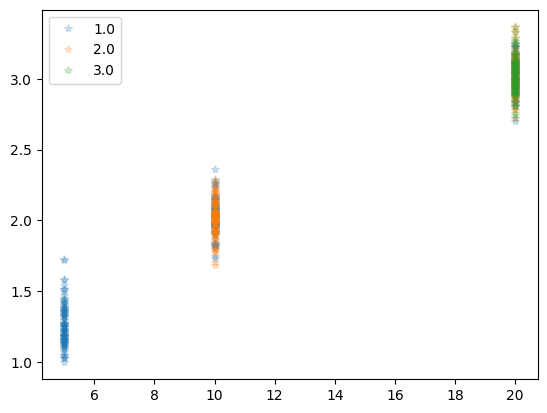

In [70]:
%matplotlib inline
i=0
for angle in list_containing_simulated_data_sorted_by_angles.keys():
    subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]
    print(angle)
    for simulation_data in subset_given_angle:
        plt.plot(simulation_data['group_size'],
                    simulation_data['group_diameter'], 
                '*',label=simulation_data["focal_bat"][0][0],alpha=0.2)
        i+=1
    plt.legend()
    plt.show()

In [75]:
data= array_containing_all_simulation_datasets_raw[0]
print(data["focal_bat"][0])
np.unique(data["group_size"], return_counts=True)

[1.         1.57079633]


(array([ 5, 10, 20]), array([100, 100, 100]))